In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


#  importing dataset from kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Testing:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


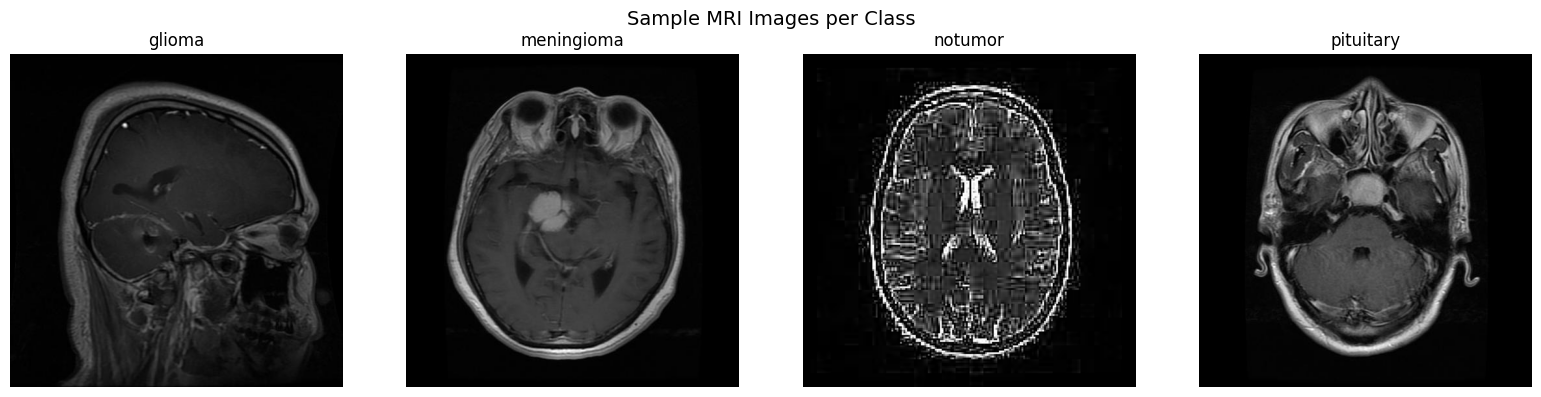

In [2]:
TRAIN_DIR = os.path.join(path, "Training")
TEST_DIR  = os.path.join(path, "Testing")

# Sort by common brain tumor types

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASS_NAMES)

# Count images per class
for split_name, split_dir in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    print(f"\n{split_name}:")
    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            print(f"  {cls}: {len(os.listdir(cls_path))} images")

# Show one sample image per class
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(16, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample = os.listdir(cls_path)[0]
    img = load_img(os.path.join(cls_path, sample))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample MRI Images per Class", fontsize=14)
plt.tight_layout()
plt.show()

 DEGRADATION TYPES
  Gaussian Noise       | param: std    | range: [0.02, 0.05, 0.1, 0.15, 0.2]
  Salt & Pepper        | param: amount | range: [0.01, 0.03, 0.05, 0.08, 0.1]
  Contrast Reduction   | param: factor | range: [0.8, 0.6, 0.4, 0.2, 0.1]
  Speckle Noise        | param: std    | range: [0.05, 0.1, 0.15, 0.2, 0.3]

Loading images at 64x64 resolution...
Training set: (5600, 64, 64, 3), Test set: (1600, 64, 64, 3)
Train: (4480, 64, 64, 3), Val: (1120, 64, 64, 3), Test: (1600, 64, 64, 3)


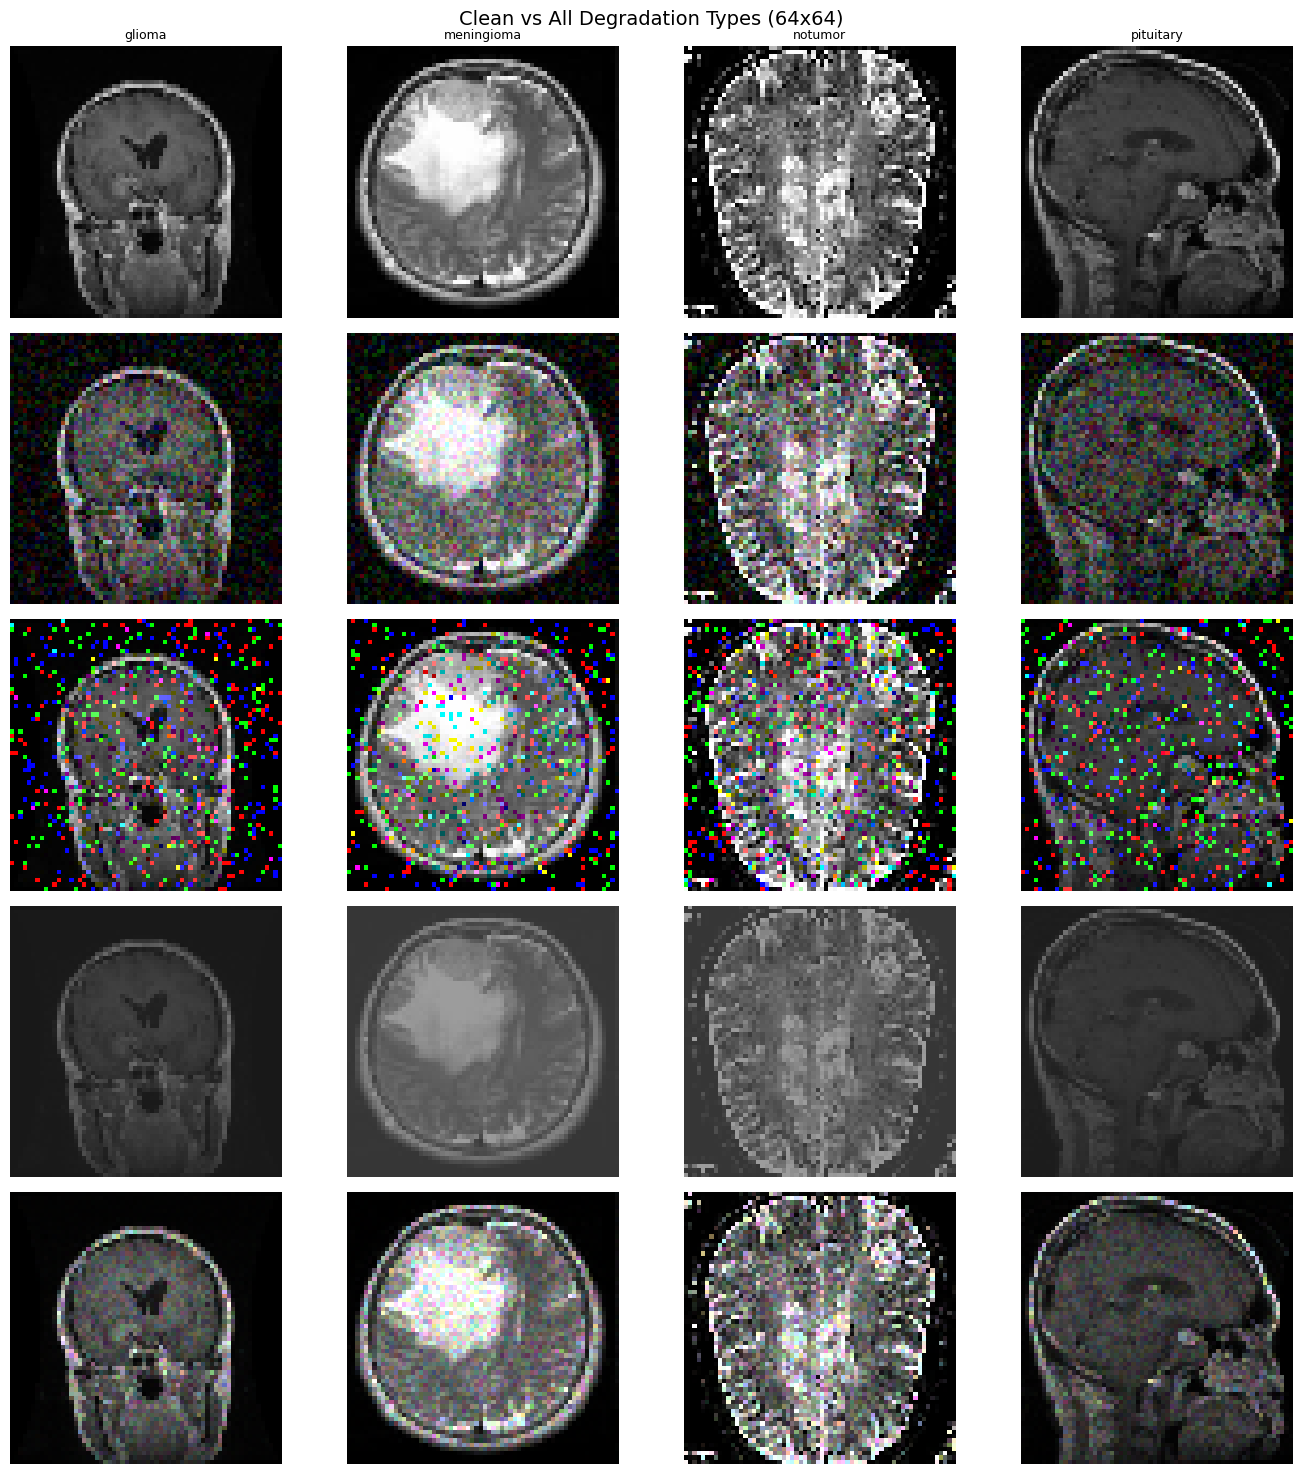

In [3]:
# configuration
IMG_SIZE = 64
NUM_CLASSES = len(CLASS_NAMES)

# degrading images
from scipy.ndimage import gaussian_filter

def add_gaussian_noise_deg(images, std=0.05):
    """Additive Gaussian noise."""
    noise = np.random.normal(0, std, images.shape)
    return np.clip(images + noise, 0.0, 1.0)

def add_salt_and_pepper(images, amount=0.05):
    """Salt-and-pepper (impulse) noise."""
    out = images.copy()
    num_salt = int(amount * images[0].size * len(images))
    coords = tuple(np.random.randint(0, d, num_salt) for d in [len(images)] + list(images.shape[1:]))
    out[coords] = 1.0
    num_pepper = int(amount * images[0].size * len(images))
    coords = tuple(np.random.randint(0, d, num_pepper) for d in [len(images)] + list(images.shape[1:]))
    out[coords] = 0.0
    return out

def reduce_contrast(images, factor=0.5):
    """Reduce contrast toward the mean."""
    mean = images.mean(axis=(1, 2, 3), keepdims=True)
    return np.clip(mean + factor * (images - mean), 0.0, 1.0)

def add_speckle_noise(images, std=0.05):
    """Multiplicative speckle noise (common in medical imaging)."""
    noise = np.random.normal(0, std, images.shape)
    return np.clip(images + images * noise, 0.0, 1.0)

DEGRADATIONS = {
    "Gaussian Noise":    (add_gaussian_noise_deg, "std",    [0.02, 0.05, 0.10, 0.15, 0.20]),
    "Salt & Pepper":     (add_salt_and_pepper,    "amount", [0.01, 0.03, 0.05, 0.08, 0.10]),
    "Contrast Reduction":(reduce_contrast,         "factor", [0.8,  0.6,  0.4,  0.2,  0.1]),
    "Speckle Noise":     (add_speckle_noise,      "std",    [0.05, 0.10, 0.15, 0.20, 0.30]),
}

# printing degredation types for reference
print(" DEGRADATION TYPES")
for deg_name, (deg_fn, param_name, values) in DEGRADATIONS.items():
    print(f"  {deg_name:20s} | param: {param_name:6s} | range: {values}")

def load_dataset(data_dir, img_size):
    """Load all images from a directory into arrays."""
    images, labels = [], []
    for label_idx, cls in enumerate(CLASS_NAMES):
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                img = load_img(fpath, target_size=(img_size, img_size))
                images.append(img_to_array(img) / 255.0)
                labels.append(label_idx)
            except Exception:
                continue
    return np.array(images), np.array(labels)

print(f"\nLoading images at {IMG_SIZE}x{IMG_SIZE} resolution...")
X_train_full, y_train_full = load_dataset(TRAIN_DIR, IMG_SIZE)
X_test, y_test = load_dataset(TEST_DIR, IMG_SIZE)
print(f"Training set: {X_train_full.shape}, Test set: {X_test.shape}")

# Split training into train + validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Create noisy test set for robustness evaluation later
X_test_noisy = add_gaussian_noise_deg(X_test, std=0.10)

# Clean vs. Degraded
# Pick one sample per class so all tumor types are shown
sample_indices = []
for cls_idx in range(NUM_CLASSES):
    idx = np.where(y_test == cls_idx)[0][0]
    sample_indices.append(idx)
n_samples = len(sample_indices)

n_rows = 1 + len(DEGRADATIONS)  # clean row + one row per degradation
fig, axes = plt.subplots(n_rows, n_samples, figsize=(14, 3 * n_rows))

# Row 0: Clean images (one per class)
for j, idx in enumerate(sample_indices):
    axes[0, j].imshow(X_test[idx])
    axes[0, j].set_title(CLASS_NAMES[y_test[idx]], fontsize=9)
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=10, rotation=0, labelpad=70, va='center')

# Rows 1+: Each degradation type at a moderate intensity
for row, (deg_name, (deg_fn, param_name, values)) in enumerate(DEGRADATIONS.items(), start=1):
    mid_val = values[len(values) // 2]  # pick middle intensity
    X_deg = deg_fn(X_test[sample_indices], **{param_name: mid_val})
    for j in range(n_samples):
        axes[row, j].imshow(X_deg[j])
        axes[row, j].axis("off")
    axes[row, 0].set_ylabel(f"{deg_name}\n({param_name}={mid_val})",
                             fontsize=9, rotation=0, labelpad=80, va='center')

plt.suptitle(f"Clean vs All Degradation Types ({IMG_SIZE}x{IMG_SIZE})", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Build CNN Model
def build_cnn(img_size, num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_size, img_size, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ])
    return model

model = build_cnn(IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,409,188 (13.01 MB)

 Trainable params: 3,405,732 (12.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [5]:
# Data Augmentation + training
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
])

BATCH_SIZE = 32
EPOCHS = 50

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train)).batch(BATCH_SIZE).map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

callbacks = [
    #Added this because the model was overfitting/not improving
    keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True, monitor='val_accuracy', mode='max'),
    keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_accuracy', mode='max', min_delta=1e-4),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=6, monitor='val_loss', min_lr=1e-6),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle(f"Training Curves ({IMG_SIZE}x{IMG_SIZE} Low-Res Model)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Evaluate on Clean Test Data
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (Clean, {IMG_SIZE}x{IMG_SIZE}): {test_acc:.4f}\n")
print("Classification Report (Clean Test Set):")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Evaluate on Noisy Test Data
y_pred_noisy_probs = model.predict(X_test_noisy)
y_pred_noisy = np.argmax(y_pred_noisy_probs, axis=1)

noisy_acc = accuracy_score(y_test, y_pred_noisy)
print(f"\nTest Accuracy (Noisy, std=0.10): {noisy_acc:.4f}\n")
print("Classification Report (Noisy Test Set):")
print(classification_report(y_test, y_pred_noisy, target_names=CLASS_NAMES))

# Summary comparison
print("\n── Robustness Summary ──")
print(f"Clean accuracy:  {test_acc:.4f}")
print(f"Noisy accuracy:  {noisy_acc:.4f}")
print(f"Accuracy drop:   {test_acc - noisy_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Test Accuracy (Clean, 64x64): 0.2550

Classification Report (Clean Test Set):
              precision    recall  f1-score   support

      glioma       0.16      0.03      0.05       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.00      0.00      0.00       400
   pituitary       0.26      0.99      0.41       400

    accuracy                           0.26      1600
   macro avg       0.11      0.26      0.11      1600
weighted avg       0.11      0.26      0.11      1600

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Test Accuracy (Noisy, std=0.10): 0.2525

Classification Report (Noisy Test Set):
              precision    recall  f1-score   support

      glioma       0.11      0.01      0.02       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.00      0.00      0.00       400
   pituitary       0.26      1.00      0.41       400

    accuracy                           0.25      1600
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Gaussian Noise: [(0.02, '0.2562'), (0.05, '0.2550'), (0.1, '0.2544'), (0.15, '0.2550'), (0.2, '0.2531')]
Salt & Pepper: [(0.01, '0.2531'), (0.03, '0.2519'), (0.05, '0.2500'), (0.08, '0.2512'), (0.1, '0.2500')]
Contrast Reduction: [(0.8, '0.2562'), (0.6, '0.2556'), (0.4, '0.2569'), (0.2, '0.2612'), (0.1, '0.2531')]
Speckle Noise: [(0.05, '0.2550'), (0.1, '0.2569'), (0.15, '0.2556'), (0.2, '0.2569'), (0.3, '0.2612')]


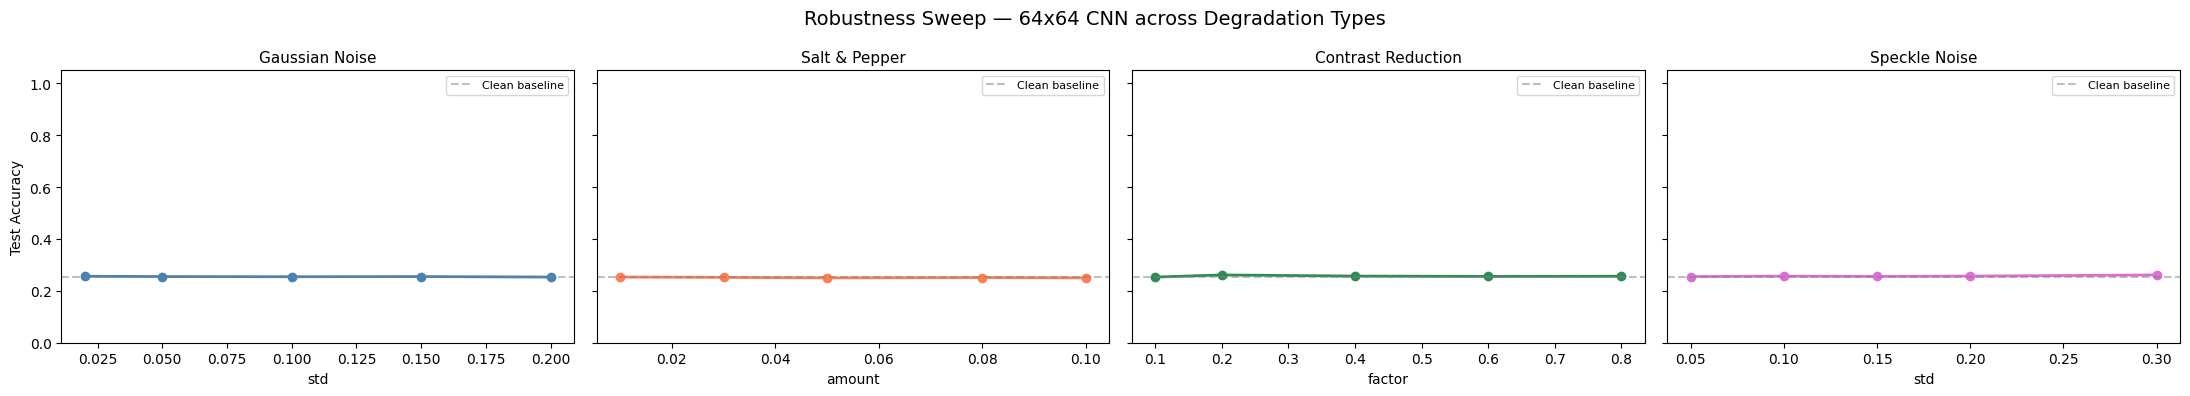

In [7]:
# Degradation Sweep: Evaluate clean-trained model across all noise types
colors = ['steelblue', 'coral', 'seagreen', 'orchid', 'goldenrod']

results = {}
for deg_name, (deg_fn, param_name, values) in DEGRADATIONS.items():
    accs = []
    for val in values:
        X_degraded = deg_fn(X_test, **{param_name: val})
        y_deg_pred = np.argmax(model.predict(X_degraded, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_deg_pred)
        accs.append(acc)
    results[deg_name] = (values, accs)
    print(f"{deg_name}: {list(zip(values, [f'{a:.4f}' for a in accs]))}")

# Plot accuracy vs degradation intensity
fig, axes = plt.subplots(1, len(DEGRADATIONS), figsize=(22, 4), sharey=True)
for ax, (deg_name, (vals, accs)), color in zip(axes, results.items(), colors):
    ax.plot(vals, accs, 'o-', color=color, linewidth=2)
    ax.axhline(y=test_acc, color='gray', linestyle='--', alpha=0.5, label='Clean baseline')
    ax.set_title(deg_name, fontsize=11)
    ax.set_xlabel(DEGRADATIONS[deg_name][1])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Test Accuracy')
plt.suptitle(f'Robustness Sweep — {IMG_SIZE}x{IMG_SIZE} CNN across Degradation Types', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Second CNN model, trained to work against noise

# Start with mild degradation, increase severity over epochs
def random_degradation_curriculum(images, epoch, total_epochs=30):
    """Scale degradation severity with training progress."""
    progress = min(epoch / (total_epochs * 0.7), 1.0)  # ramp over first 70% of training
    images = np.array(images, dtype=np.float32)
    choice = np.random.randint(0, 4)
    if choice == 0:
        std = np.random.uniform(0.02, 0.02 + 0.13 * progress)
        out = add_gaussian_noise_deg(images, std=std)
    elif choice == 1:
        amount = np.random.uniform(0.01, 0.01 + 0.07 * progress)
        out = add_salt_and_pepper(images, amount=amount)
    elif choice == 2:
        factor = np.random.uniform(0.7 - 0.5 * progress, 0.8)
        out = reduce_contrast(images, factor=factor)
    else:
        std = np.random.uniform(0.05, 0.05 + 0.15 * progress)
        out = add_speckle_noise(images, std=std)
    return out.astype(np.float32)


def random_degradation(images):
    """Apply a random degradation to a batch of images (numpy)."""
    images = np.array(images, dtype=np.float32)
    choice = np.random.randint(0, 4)
    if choice == 0:
        out = add_gaussian_noise_deg(images, std=np.random.uniform(0.02, 0.15))
    elif choice == 1:
        out = add_salt_and_pepper(images, amount=np.random.uniform(0.01, 0.08))
    elif choice == 2:
        out = reduce_contrast(images, factor=np.random.uniform(0.2, 0.7))
    else:
        out = add_speckle_noise(images, std=np.random.uniform(0.05, 0.20))
    return out.astype(np.float32)

def noise_augment_map(x, y):
    def _apply_noise(images):
        return tf.numpy_function(random_degradation, [images], tf.float32)

    degraded = _apply_noise(x)
    degraded.set_shape(x.shape)

    # 70% chance of degraded, 30% clean
    use_noise = tf.random.uniform(()) > 0.30
    out = tf.cond(use_noise, lambda: degraded, lambda: x)
    return out, y

# Build a fresh model for noise-augmented training
robust_model = build_cnn(IMG_SIZE, NUM_CLASSES)
robust_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Create noise-augmented training pipeline
train_ds_noisy = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_noisy = (
    train_ds_noisy
    .shuffle(len(X_train))
    .batch(BATCH_SIZE)
    .map(noise_augment_map, num_parallel_calls=tf.data.AUTOTUNE)      # ← degradation first
    .map(lambda x, y: (data_augmentation(x, training=True), y),       # ← geometric aug second
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# During robust model training, track BOTH clean and noisy val accuracy
X_val_noisy = add_gaussian_noise_deg(X_val, std=0.10)
val_ds_noisy = tf.data.Dataset.from_tensor_slices((X_val_noisy, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Use a custom callback to log both
class DualValCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        _, noisy_acc = self.model.evaluate(val_ds_noisy, verbose=0)
        print(f"  val_noisy_acc: {noisy_acc:.4f}")

robust_callbacks = [
    keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True,
                                   monitor='val_loss', min_delta=1e-4),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=6,
                                       monitor='val_loss', min_lr=1e-6),
    DualValCallback()
]

print("Training noise-augmented (robust) model...")
robust_history = robust_model.fit(
    train_ds_noisy,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=robust_callbacks
)

# Plot training curves for robust model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(robust_history.history['accuracy'], label='Train')
ax1.plot(robust_history.history['val_accuracy'], label='Val')
ax1.set_title('Robust Model — Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(robust_history.history['loss'], label='Train')
ax2.plot(robust_history.history['val_loss'], label='Val')
ax2.set_title('Robust Model — Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle('Training Curves: Noise-Augmented CNN', fontsize=14)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
ROBUST MODEL — Clean Test Set
Accuracy: 0.2600

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       400
  meningioma       0.25      0.85      0.38       400
     notumor       0.04      0.00      0.00       400
   pituitary       0.37      0.19      0.25       400

    accuracy                           0.26      1600
   macro avg       0.16      0.26      0.16      1600
weighted avg       0.16      0.26      0.16      1600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


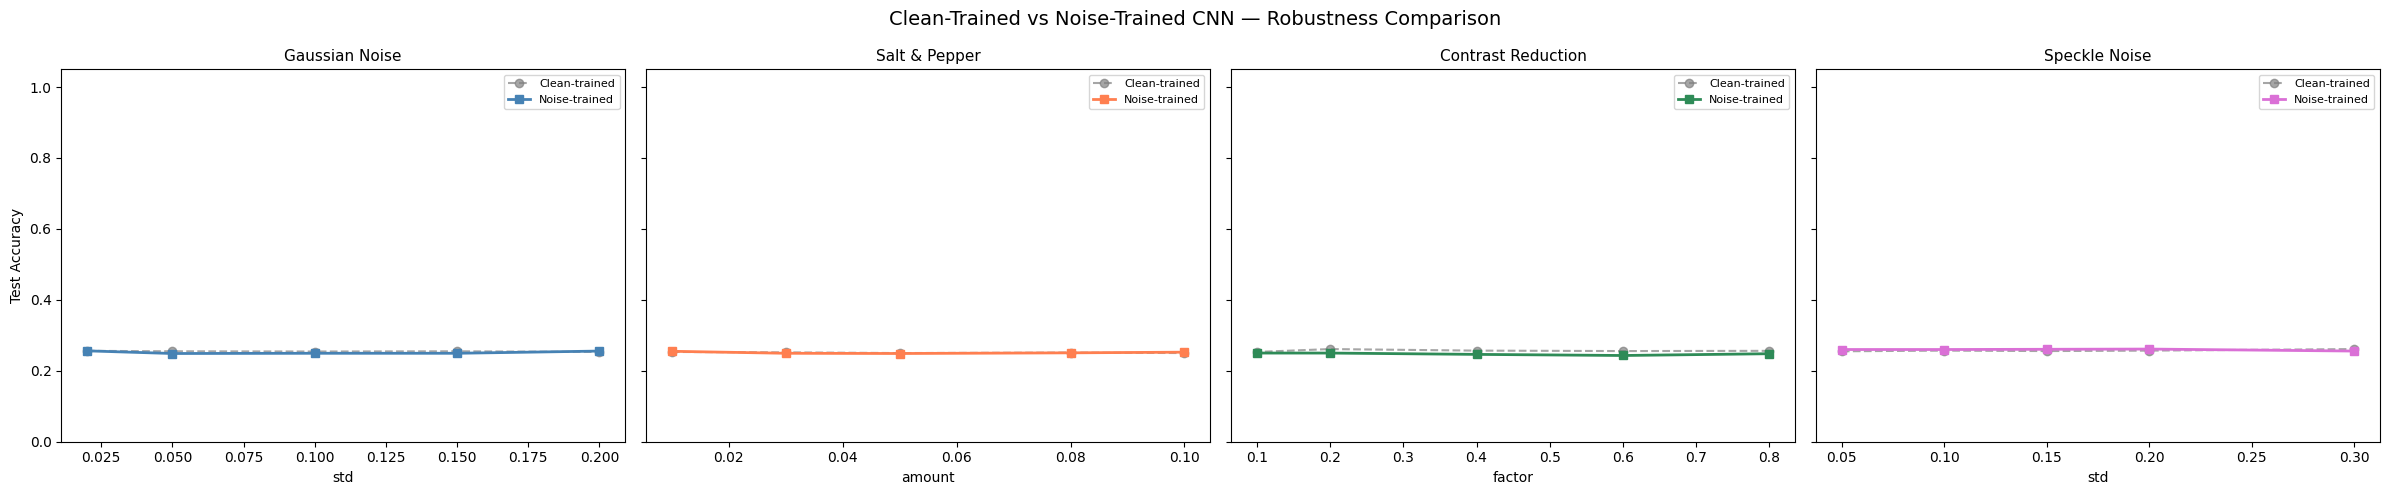

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


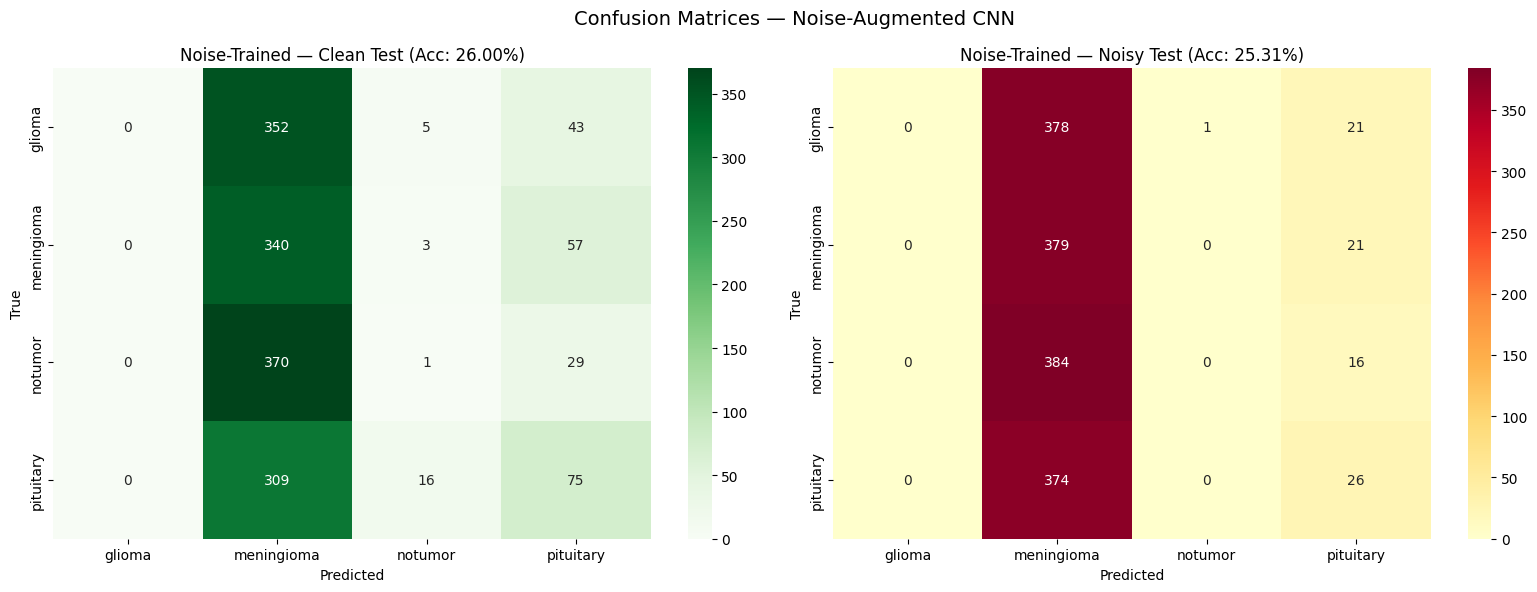


FINAL COMPARISON: CLEAN-TRAINED vs NOISE-TRAINED MODEL
       Degradation  Intensity  Clean-Trained Acc  Noise-Trained Acc  Improvement
    Gaussian Noise     0.0200             0.2562             0.2562       0.0000
    Gaussian Noise     0.0500             0.2550             0.2487      -0.0063
    Gaussian Noise     0.1000             0.2544             0.2494      -0.0050
    Gaussian Noise     0.1500             0.2550             0.2494      -0.0056
    Gaussian Noise     0.2000             0.2531             0.2556       0.0025
     Salt & Pepper     0.0100             0.2531             0.2550       0.0019
     Salt & Pepper     0.0300             0.2519             0.2494      -0.0025
     Salt & Pepper     0.0500             0.2500             0.2487      -0.0013
     Salt & Pepper     0.0800             0.2512             0.2506      -0.0006
     Salt & Pepper     0.1000             0.2500             0.2525       0.0025
Contrast Reduction     0.8000             0.2562     

In [9]:
# Copmaring models

# Testing CNN2 on clean data
y_robust_pred = np.argmax(robust_model.predict(X_test), axis=1)
robust_clean_acc = accuracy_score(y_test, y_robust_pred)

print("=" * 77)
print("ROBUST MODEL — Clean Test Set")
print("=" * 77)
print(f"Accuracy: {robust_clean_acc:.4f}\n")
print(classification_report(y_test, y_robust_pred, target_names=CLASS_NAMES))

# Testing CNN2 on degredations
robust_results = {}
for deg_name, (deg_fn, param_name, values) in DEGRADATIONS.items():
    accs = []
    for val in values:
        X_degraded = deg_fn(X_test, **{param_name: val})
        y_deg_pred = np.argmax(robust_model.predict(X_degraded, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_deg_pred)
        accs.append(acc)
    robust_results[deg_name] = (values, accs)

# Comparison plots
fig, axes = plt.subplots(1, len(DEGRADATIONS), figsize=(24, 5), sharey=True)
for ax, deg_name, color in zip(axes, DEGRADATIONS.keys(), colors):
    vals = results[deg_name][0]
    ax.plot(vals, results[deg_name][1], 'o--', color='gray', linewidth=1.5,
            label='Clean-trained', alpha=0.7)
    ax.plot(vals, robust_results[deg_name][1], 's-', color=color, linewidth=2,
            label='Noise-trained')
    ax.set_title(deg_name, fontsize=11)
    ax.set_xlabel(DEGRADATIONS[deg_name][1])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Test Accuracy')
plt.suptitle('Clean-Trained vs Noise-Trained CNN — Robustness Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Confusion matrices for robust model: clean vs worst degradation
y_robust_noisy_pred = np.argmax(robust_model.predict(X_test_noisy), axis=1)
robust_noisy_acc = accuracy_score(y_test, y_robust_noisy_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_robust_clean = confusion_matrix(y_test, y_robust_pred)
sns.heatmap(cm_robust_clean, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'Noise-Trained — Clean Test (Acc: {robust_clean_acc:.2%})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_robust_noisy = confusion_matrix(y_test, y_robust_noisy_pred)
sns.heatmap(cm_robust_noisy, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f'Noise-Trained — Noisy Test (Acc: {robust_noisy_acc:.2%})')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Confusion Matrices — Noise-Augmented CNN', fontsize=14)
plt.tight_layout()
plt.show()

# FINAL COMPARISON TABLE
print("\n" + "=" * 77)
print("FINAL COMPARISON: CLEAN-TRAINED vs NOISE-TRAINED MODEL")
print("=" * 77)
summary_data = []
for deg_name in DEGRADATIONS:
    vals = results[deg_name][0]
    for i, val in enumerate(vals):
        summary_data.append({
            'Degradation': deg_name,
            'Intensity': val,
            'Clean-Trained Acc': results[deg_name][1][i],
            'Noise-Trained Acc': robust_results[deg_name][1][i],
            'Improvement': robust_results[deg_name][1][i] - results[deg_name][1][i]
        })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False, float_format='%.4f'))

# Overall averages
avg_clean_model = df_summary['Clean-Trained Acc'].mean()
avg_robust_model = df_summary['Noise-Trained Acc'].mean()
print(f"\nAvg accuracy across all degradations:")
print(f"  Clean-trained model:  {avg_clean_model:.4f}")
print(f"  Noise-trained model:  {avg_robust_model:.4f}")
print(f"  Average improvement:  {avg_robust_model - avg_clean_model:+.4f}")

## DenseNet Implementation
Building and training a DenseNet model for comparison.

In [10]:
# Build DenseNet Model
# We use DenseNet121 from keras.applications

def build_densenet(img_size, num_classes):
    base_model = keras.applications.DenseNet121(
        weights=None,
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

densenet_model = build_densenet(IMG_SIZE, NUM_CLASSES)

densenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

densenet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 2, 2, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,566,404 (28.86 MB)

 Trainable params: 7,481,732 (28.54 MB)

 Non-trainable params: 84,672 (330.75 KB)

Training DenseNet model...
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 167s 155ms/step - accuracy: 0.6308 - loss: 1.0030 - val_accuracy: 0.2562 - val_loss: 1.4379 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.7074 - loss: 0.7741 - val_accuracy: 0.4625 - val_loss: 1.2747 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.7402 - loss: 0.6915 - val_accuracy: 0.5339 - val_loss: 1.0942 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.7585 - loss: 0.6411 - val_accuracy: 0.3911 - val_loss: 1.3096 - learning_rate: 0.0010
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.7933 - loss: 0.5541 - val_accuracy: 0.2732 - val_loss: 4.1088 - learning_rate: 0.0010
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.8007 - loss: 0.5462 - val_accuracy: 0.2571 - val_loss: 6.4220 - learning_rate: 0.0010
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms

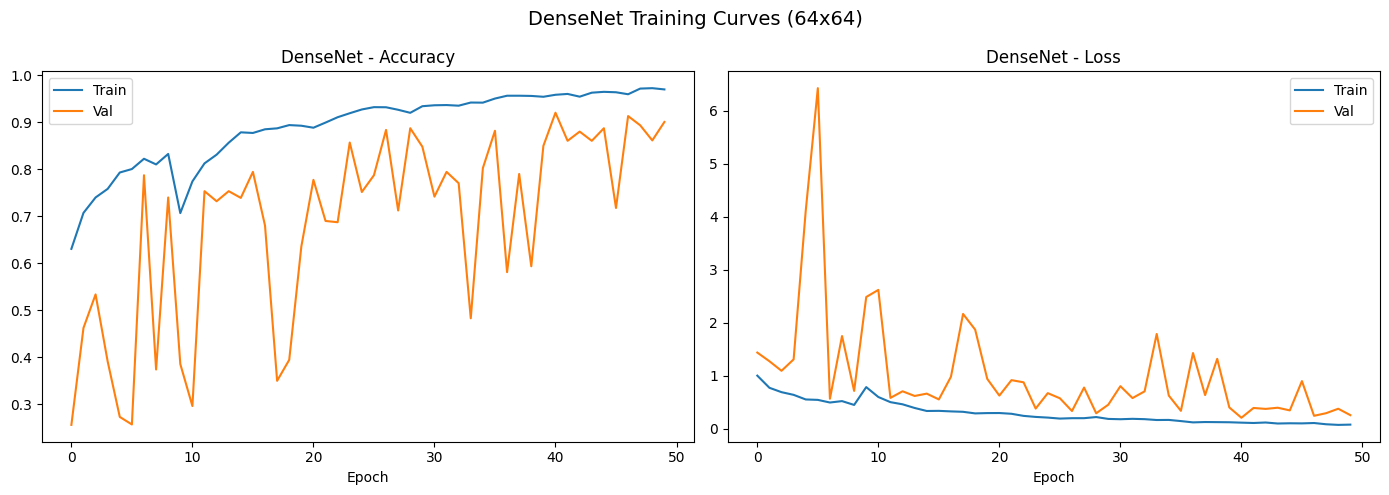

In [11]:
# Train DenseNet on clean data (using the same augmented dataset as before)
print("Training DenseNet model...")

densenet_history = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Plot training curves for DenseNet
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(densenet_history.history['accuracy'], label='Train')
ax1.plot(densenet_history.history['val_accuracy'], label='Val')
ax1.set_title('DenseNet - Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(densenet_history.history['loss'], label='Train')
ax2.plot(densenet_history.history['val_loss'], label='Val')
ax2.set_title('DenseNet - Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.suptitle(f"DenseNet Training Curves ({IMG_SIZE}x{IMG_SIZE})", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Evaluate DenseNet on Clean Data
y_pred_probs_dn = densenet_model.predict(X_test)
y_pred_dn = np.argmax(y_pred_probs_dn, axis=1)

test_acc_dn = accuracy_score(y_test, y_pred_dn)
print(f"DenseNet Test Accuracy (Clean, {IMG_SIZE}x{IMG_SIZE}): {test_acc_dn:.4f}\n")
print("Classification Report (DenseNet - Clean Test Set):")
print(classification_report(y_test, y_pred_dn, target_names=CLASS_NAMES))

# Evaluate DenseNet on Noisy Test Data
y_pred_noisy_probs_dn = densenet_model.predict(X_test_noisy)
y_pred_noisy_dn = np.argmax(y_pred_noisy_probs_dn, axis=1)

noisy_acc_dn = accuracy_score(y_test, y_pred_noisy_dn)
print(f"\nDenseNet Test Accuracy (Noisy, std=0.10): {noisy_acc_dn:.4f}\n")
print("Classification Report (DenseNet - Noisy Test Set):")
print(classification_report(y_test, y_pred_noisy_dn, target_names=CLASS_NAMES))

# Summary comparison
print("\n── DenseNet Robustness Summary ──")
print(f"Clean accuracy:  {test_acc_dn:.4f}")
print(f"Noisy accuracy:  {noisy_acc_dn:.4f}")
print(f"Accuracy drop:   {test_acc_dn - noisy_acc_dn:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step
DenseNet Test Accuracy (Clean, 64x64): 0.8825

Classification Report (DenseNet - Clean Test Set):
              precision    recall  f1-score   support

      glioma       0.96      0.68      0.79       400
  meningioma       0.83      0.92      0.87       400
     notumor       0.83      0.97      0.90       400
   pituitary       0.95      0.96      0.96       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

DenseNet Test Accuracy (Noisy, std=0.10): 0.5637

Classification Report (DenseNet - Noisy Test Set):
              precision    recall  f1-score   support

      glioma       0.82      0.04      0.07       400
  meningioma       0.78      0.49      0.61       400
     notumor       0.38      0.97      0.55       400
   pituitary       0.98      0.75      0.85       400

    accuracy

DenseNet Degradation Sweep Results:
Gaussian Noise: [(0.02, '0.8512'), (0.05, '0.7762'), (0.1, '0.5663'), (0.15, '0.3175'), (0.2, '0.2819')]
Salt & Pepper: [(0.01, '0.7969'), (0.03, '0.4888'), (0.05, '0.3175'), (0.08, '0.2787'), (0.1, '0.2662')]
Contrast Reduction: [(0.8, '0.7694'), (0.6, '0.5469'), (0.4, '0.3994'), (0.2, '0.3256'), (0.1, '0.3244')]
Speckle Noise: [(0.05, '0.8838'), (0.1, '0.8812'), (0.15, '0.8794'), (0.2, '0.8644'), (0.3, '0.8113')]


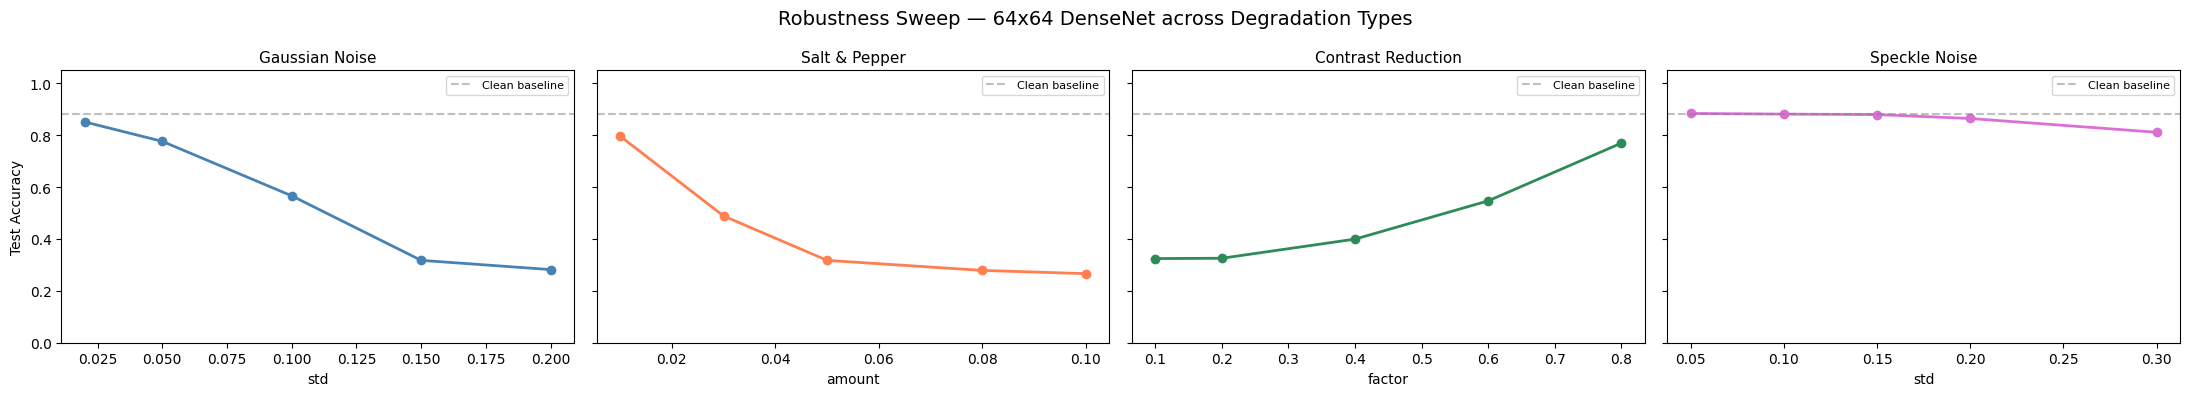

In [13]:
# Degradation Sweep: Evaluate DenseNet across all noise types
colors = ['steelblue', 'coral', 'seagreen', 'orchid', 'goldenrod']

results_dn = {}
print("DenseNet Degradation Sweep Results:")
for deg_name, (deg_fn, param_name, values) in DEGRADATIONS.items():
    accs = []
    for val in values:
        X_degraded = deg_fn(X_test, **{param_name: val})
        y_deg_pred = np.argmax(densenet_model.predict(X_degraded, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_deg_pred)
        accs.append(acc)
    results_dn[deg_name] = (values, accs)
    print(f"{deg_name}: {list(zip(values, [f'{a:.4f}' for a in accs]))}")

# Plot accuracy vs degradation intensity for DenseNet
fig, axes = plt.subplots(1, len(DEGRADATIONS), figsize=(22, 4), sharey=True)
for ax, (deg_name, (vals, accs)), color in zip(axes, results_dn.items(), colors):
    ax.plot(vals, accs, 'o-', color=color, linewidth=2)
    ax.axhline(y=test_acc_dn, color='gray', linestyle='--', alpha=0.5, label='Clean baseline')
    ax.set_title(deg_name, fontsize=11)
    ax.set_xlabel(DEGRADATIONS[deg_name][1])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Test Accuracy')
plt.suptitle(f'Robustness Sweep — {IMG_SIZE}x{IMG_SIZE} DenseNet across Degradation Types', fontsize=14)
plt.tight_layout()
plt.show()

Training noise-augmented (robust) DenseNet model...
Epoch 1/50
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5608 - loss: 1.2117  val_noisy_acc: 0.2509
140/140 ━━━━━━━━━━━━━━━━━━━━ 172s 249ms/step - accuracy: 0.6007 - loss: 1.0727 - val_accuracy: 0.2509 - val_loss: 1.5547 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6687 - loss: 0.8770  val_noisy_acc: 0.2839
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.6750 - loss: 0.8582 - val_accuracy: 0.2866 - val_loss: 2.2716 - learning_rate: 0.0010
Epoch 3/50
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7172 - loss: 0.7410  val_noisy_acc: 0.5696
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.7190 - loss: 0.7284 - val_accuracy: 0.5366 - val_loss: 1.0606 - learning_rate: 0.0010
Epoch 4/50
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7331 - loss: 0.7404  val_noisy_acc: 0.7161
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.7350 - loss: 0.7307 

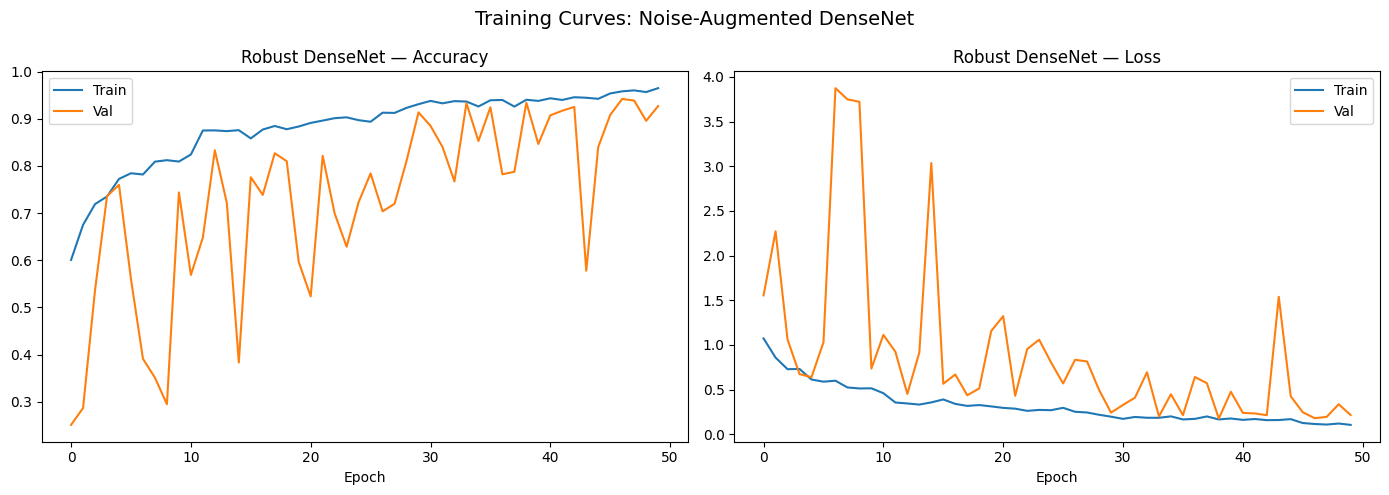

In [14]:
# Build robust DenseNet model
robust_densenet_model = build_densenet(IMG_SIZE, NUM_CLASSES)
robust_densenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training noise-augmented (robust) DenseNet model...")
robust_densenet_history = robust_densenet_model.fit(
    train_ds_noisy, # Using the noisy dataset pipeline created earlier
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=robust_callbacks
)

# Plot training curves for robust DenseNet
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(robust_densenet_history.history['accuracy'], label='Train')
ax1.plot(robust_densenet_history.history['val_accuracy'], label='Val')
ax1.set_title('Robust DenseNet — Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax2.plot(robust_densenet_history.history['loss'], label='Train')
ax2.plot(robust_densenet_history.history['val_loss'], label='Val')
ax2.set_title('Robust DenseNet — Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.suptitle('Training Curves: Noise-Augmented DenseNet', fontsize=14)
plt.tight_layout()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step
ROBUST DENSENET MODEL — Clean Test Set
Accuracy: 0.8819

              precision    recall  f1-score   support

      glioma       0.90      0.72      0.80       400
  meningioma       0.86      0.87      0.86       400
     notumor       0.83      0.99      0.90       400
   pituitary       0.95      0.94      0.95       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



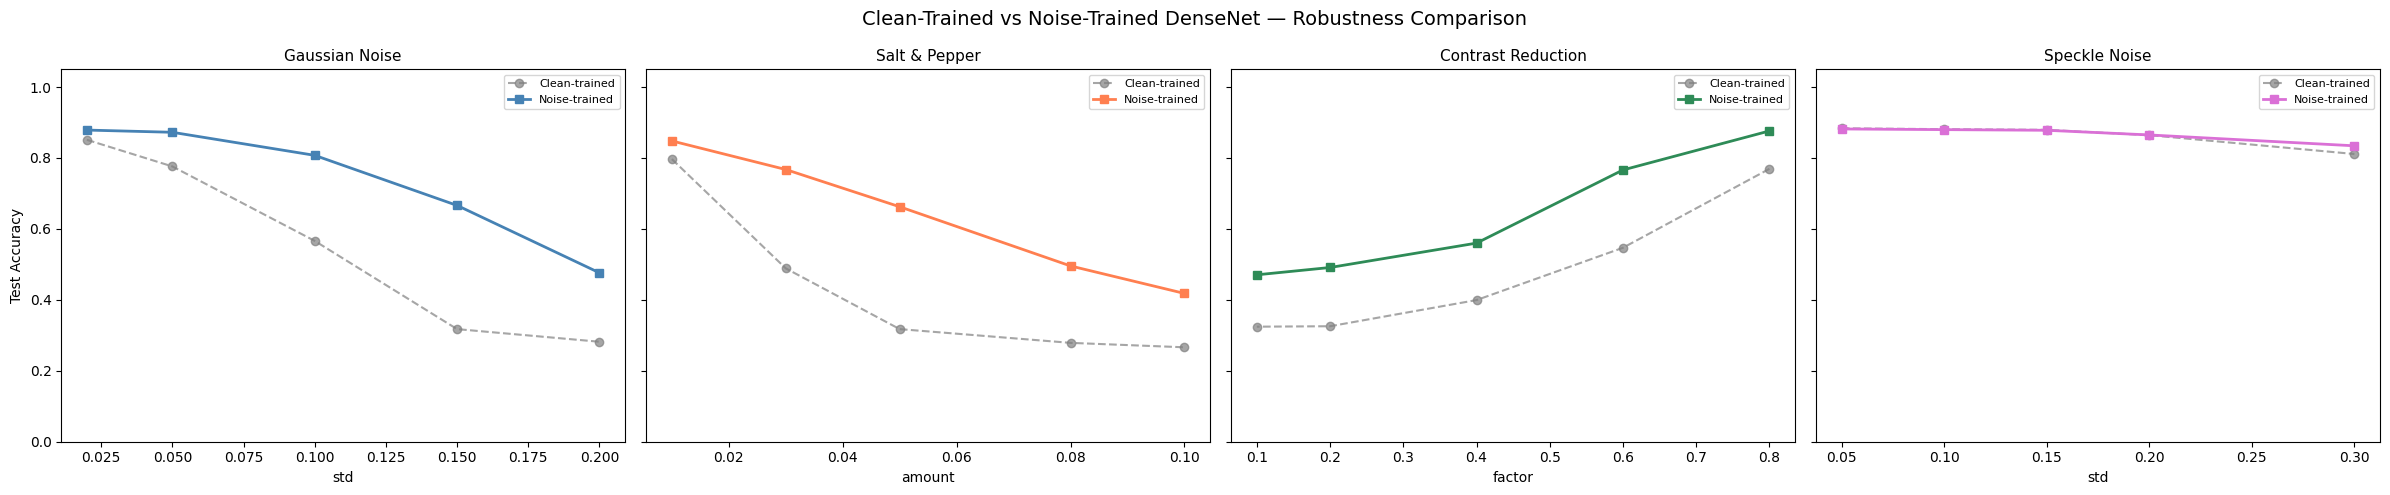

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


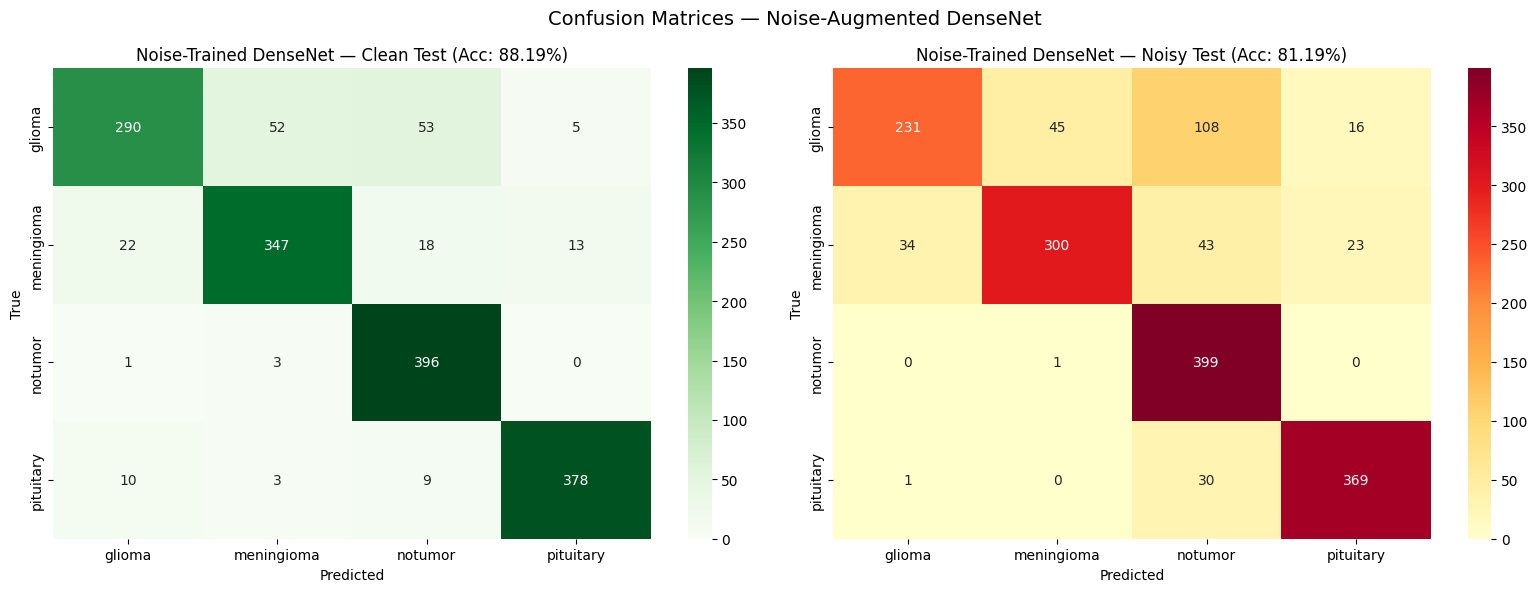


FINAL COMPARISON: CLEAN-TRAINED vs NOISE-TRAINED DENSENET
       Degradation  Intensity  Clean-Trained Acc  Noise-Trained Acc  Improvement
    Gaussian Noise     0.0200             0.8512             0.8788       0.0275
    Gaussian Noise     0.0500             0.7762             0.8725       0.0963
    Gaussian Noise     0.1000             0.5663             0.8075       0.2412
    Gaussian Noise     0.1500             0.3175             0.6663       0.3488
    Gaussian Noise     0.2000             0.2819             0.4763       0.1944
     Salt & Pepper     0.0100             0.7969             0.8481       0.0513
     Salt & Pepper     0.0300             0.4888             0.7675       0.2787
     Salt & Pepper     0.0500             0.3175             0.6625       0.3450
     Salt & Pepper     0.0800             0.2787             0.4956       0.2169
     Salt & Pepper     0.1000             0.2662             0.4181       0.1519
Contrast Reduction     0.8000             0.7694  

In [15]:
# Comparing DenseNet models

# Testing Robust DenseNet on clean data
y_robust_pred_dn = np.argmax(robust_densenet_model.predict(X_test), axis=1)
robust_clean_acc_dn = accuracy_score(y_test, y_robust_pred_dn)

print("=" * 77)
print("ROBUST DENSENET MODEL — Clean Test Set")
print("=" * 77)
print(f"Accuracy: {robust_clean_acc_dn:.4f}\n")
print(classification_report(y_test, y_robust_pred_dn, target_names=CLASS_NAMES))

# Testing Robust DenseNet on degradations
robust_results_dn = {}
for deg_name, (deg_fn, param_name, values) in DEGRADATIONS.items():
    accs = []
    for val in values:
        X_degraded = deg_fn(X_test, **{param_name: val})
        y_deg_pred = np.argmax(robust_densenet_model.predict(X_degraded, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_deg_pred)
        accs.append(acc)
    robust_results_dn[deg_name] = (values, accs)

# Comparison plots
fig, axes = plt.subplots(1, len(DEGRADATIONS), figsize=(24, 5), sharey=True)
for ax, deg_name, color in zip(axes, DEGRADATIONS.keys(), colors):
    vals = results_dn[deg_name][0]
    ax.plot(vals, results_dn[deg_name][1], 'o--', color='gray', linewidth=1.5,
            label='Clean-trained', alpha=0.7)
    ax.plot(vals, robust_results_dn[deg_name][1], 's-', color=color, linewidth=2,
            label='Noise-trained')
    ax.set_title(deg_name, fontsize=11)
    ax.set_xlabel(DEGRADATIONS[deg_name][1])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Test Accuracy')
plt.suptitle('Clean-Trained vs Noise-Trained DenseNet — Robustness Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Confusion matrices for robust model: clean vs worst degradation
y_robust_noisy_pred_dn = np.argmax(robust_densenet_model.predict(X_test_noisy), axis=1)
robust_noisy_acc_dn = accuracy_score(y_test, y_robust_noisy_pred_dn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_robust_clean_dn = confusion_matrix(y_test, y_robust_pred_dn)
sns.heatmap(cm_robust_clean_dn, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'Noise-Trained DenseNet — Clean Test (Acc: {robust_clean_acc_dn:.2%})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_robust_noisy_dn = confusion_matrix(y_test, y_robust_noisy_pred_dn)
sns.heatmap(cm_robust_noisy_dn, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f'Noise-Trained DenseNet — Noisy Test (Acc: {robust_noisy_acc_dn:.2%})')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Confusion Matrices — Noise-Augmented DenseNet', fontsize=14)
plt.tight_layout()
plt.show()

# FINAL COMPARISON TABLE
print("\n" + "=" * 77)
print("FINAL COMPARISON: CLEAN-TRAINED vs NOISE-TRAINED DENSENET")
print("=" * 77)
summary_data_dn = []
for deg_name in DEGRADATIONS:
    vals = results_dn[deg_name][0]
    for i, val in enumerate(vals):
        summary_data_dn.append({
            'Degradation': deg_name,
            'Intensity': val,
            'Clean-Trained Acc': results_dn[deg_name][1][i],
            'Noise-Trained Acc': robust_results_dn[deg_name][1][i],
            'Improvement': robust_results_dn[deg_name][1][i] - results_dn[deg_name][1][i]
        })

df_summary_dn = pd.DataFrame(summary_data_dn)
print(df_summary_dn.to_string(index=False, float_format='%.4f'))

# Overall averages
avg_clean_model_dn = df_summary_dn['Clean-Trained Acc'].mean()
avg_robust_model_dn = df_summary_dn['Noise-Trained Acc'].mean()
print(f"\nAvg accuracy across all degradations (DenseNet):")
print(f"  Clean-trained model:  {avg_clean_model_dn:.4f}")
print(f"  Noise-trained model:  {avg_robust_model_dn:.4f}")
print(f"  Average improvement:  {avg_robust_model_dn - avg_clean_model_dn:+.4f}")